In [175]:
using DifferentialEquations
using LinearAlgebra
using JuMP
using Plots
using StatsPlots

In [2]:
struct SimpleHarmonicOscillator
    m::Float64
    c::Float64
    k::Float64
    F::Float64
    w::Float64
end

function HarmonicChecker(oscillator::SimpleHarmonicOscillator)
    # @assert oscillator.m > 0
    # @assert oscillator.c >= 0
    # @assert oscillator.k >= 0
    if oscillator.m > 0 && oscillator.c >= 0 && oscillator.k >= 0
        return oscillator
    else
        return "Invalid"
    end
end



HarmonicChecker (generic function with 1 method)

In [148]:
function state_matrix(p::SimpleHarmonicOscillator)
    A = [0 1; -1*(p.k/p.m) -1*(p.c/p.m)]
    return A
end

function input_vector(p::SimpleHarmonicOscillator)
    B = [0; (p.F/p.m)]
end

function control(t, p::SimpleHarmonicOscillator)
    u = cos(t*p.w)
    return u
end

function harmonic_oscillator!(dx, x, p, t)
    A = state_matrix(p)
    B = input_vector(p)
    U =  control(t, p)
    dx .= A * x + B * U
return nothing
end


harmonic_oscillator! (generic function with 1 method)

In [149]:
abstract type AbstractODESolver end

struct ForwardEuler <: AbstractODESolver end
struct RungeKutta4 <: AbstractODESolver end
struct BackwardEuler <: AbstractODESolver end
struct SymplecticEuler <: AbstractODESolver end


function step!(::ForwardEuler,f!, xnext, x, p, t, dt)
    dx = similar(x)
    f!(dx, x, p, t)
    xnext .= x + dt.* dx
    return xnext
end

struct MyODEProblem{F,U,TS,P}
    f!::F
    u0::U
    tspan::TS
    p::P
end

struct ODESolution{T,U}
    t::T
    u::U
end

function integrate(problem::MyODEProblem, solver::AbstractODESolver; dt)
t0, tf = problem.tspan
@assert tf > t0
@assert dt > 0
# if !(tf > t0 && dt > 0)
#     return error()
# end

nsteps = Int(ceil((tf-t0)/dt))
times = range(t0, tf, length = nsteps + 1)
states = [
    similar(problem.u0)
    for _ in eachindex(times)
]
states[1] .= problem.u0
for n in 1:nsteps
    step!(solver, problem.f!, states[n+1], states[n], problem.p, times[n], dt)
    # TODO: call step!
end
return ODESolution(times, states)
end

integrate (generic function with 1 method)

In [150]:
function exact_undamped(ts, x0, p)
    q0, v0 = x0
    ω0 = sqrt(p.k/p.m) 
    q = q0 .* cos.(ω0 .* ts) .+ (v0 / ω0) .* sin.(ω0 .* ts)
    v = -q0 * ω0 .* sin.(ω0 .* ts) .+ v0 .* cos.(ω0 .* ts)
return [q'; v']
end

function energy(x, p::SimpleHarmonicOscillator)
    q, v = x
    E = 0.5 * (p.m .* x[2]^2 + p.k .* x[1]^2)
    return E
end


energy (generic function with 2 methods)

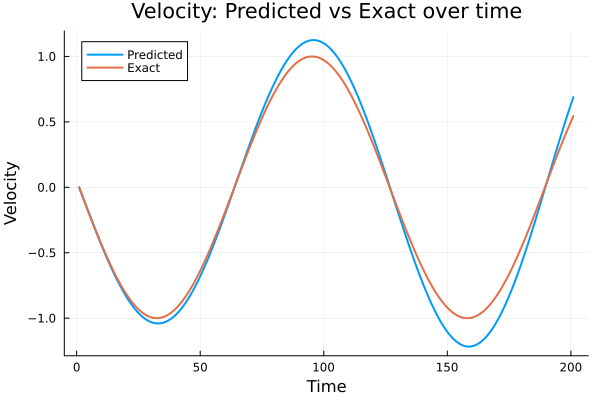

In [178]:
oscillator = SimpleHarmonicOscillator(1,0,1,0,0)
tspan = (0.0,10.0)
dt = 0.05
u0 = [1.0; 0.0]
problem = MyODEProblem(harmonic_oscillator!, u0, tspan, oscillator)
solver = ForwardEuler()
integrator = integrate(problem, solver, dt = dt)

R = integrator.t
D = integrator.u

Q_index = []
V_index = []
for i in range(1, length(D))
    append!(Q_index,D[i][1])
end

for i in range(1, length(D))
    append!(V_index,D[i][2])
end

Exact = exact_undamped(R, u0, oscillator)
Q_lst = []
V_lst = []
for i in range(1, length(Exact))
    if iseven(i)
        append!(V_lst, Exact[i])
    else
        append!(Q_lst, Exact[i])
    end
end
#Index means predicted
#Lst means exact

#POSITION V TIME
Plots.plot(Q_index, title = "Position: Predicted vs Exact over time", xlabel = "Time", ylabel = "Position", label = "Predicted", width = 2)
Plots.plot!(Q_lst, label = "Exact", width = 2)

#VELOCITY V TIME
Plots.plot(V_index, title = "Velocity: Predicted vs Exact over time", xlabel = "Time", ylabel = "Velocity", label = "Predicted", width = 2)
Plots.plot!(V_lst, label = "Exact", width = 2)

#POSITION V VELOCITY Predicted
#Plots.plot(Q_index, V_index, title = "Pos v Vel: Predicted", xlabel = "Position", ylabel = "Velocity", label = "Predicted", width = 2)
#Plots.plot!(Q_index, V_lst, label = "Exact", width = 2)




In [211]:
function step!(::RungeKutta4, f!, xnext, x, p, t, dt)
    k1 = similar(x)
    k2 = similar(x)
    k3 = similar(x)
    k4 = similar(x)
    temporary = similar(x)

    f!(k1, x, p, t)
    x2 = x + dt * k1 * 1/2
    f!(k2, x2, p, t + dt/2)
    x3 = x + dt * k2 * 1/2
    f!(k3, x3, p, t + dt/2)
    x4 = x + dt * k3
    f!(k4, x4, p, t + dt)

    xnext .= x + dt/6 * (k1 + 2k2 + 2k3 + k4)
return xnext
end


function step!(::BackwardEuler, f!, xnext, x, p::SimpleHarmonicOscillator, t, dt)
A = state_matrix(p)
B = input_vector(p)
n = size(A)
L = Matrix(I, n, n) - dt * A
R = x + dt * B * control(t + dt, p)

xnext = L \ R
return xnext
end


function step!(::SymplecticEuler, f!, xnext, x, p::SimpleHarmonicOscillator, t, dt)
q, v = x
    dx = similar(x)
    f!(dx, x, p, t)
    a = dx[2] 
    v1 = x[2] + dt * a
    q1 = x[1] + dt * v1
    
    xnext[1] = q1
    xnext[2] = v1
return xnext
end

step! (generic function with 4 methods)

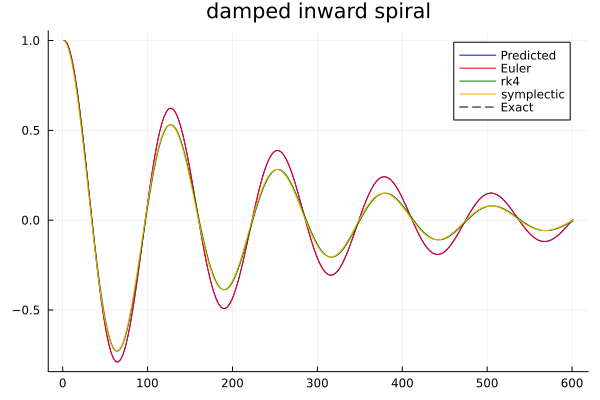

In [238]:
euler_solution = integrate(problem, ForwardEuler(); dt = 0.05)

rk4_solution = integrate(problem, RungeKutta4(); dt = 0.05)

symplectic_solution = integrate(problem, SymplecticEuler(); dt = 0.05) 

function Plot_helper(solution)
    Q_lst = []
    V_lst = []
    for i in range(1, length(solution.u))
        append!(Q_lst,solution.u[i][1])
    end

    for i in range(1, length(solution.u))
        append!(V_lst,solution.u[i][2])
    end
    return [Q_lst, V_lst]
end

function Plotter(case::NamedTuple)
    problem = MyODEProblem(harmonic_oscillator!, case.u0, case.tspan, case.p)

    euler_solution = integrate(problem, ForwardEuler(); dt = case.dt)
    rk4_solution = integrate(problem, RungeKutta4(); dt = case.dt)
    symplectic_solution = integrate(problem, SymplecticEuler(); dt = case.dt) 
    integrator = integrate(problem, ForwardEuler(), dt = case.dt)

    Exact = exact_undamped(integrator.t, case.u0, case.p)
    Exact = []
    Exact_lst_q = []
    Exact_lst_v = []
    for i in range(1, length(Exact))
        if iseven(i)
            append!(Exact_lst_q, Exact[i])
        else
            append!(Exact_lst_v, Exact[i])
        end
    end
 

    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    Euler = Plot_helper(euler_solution)
    RK4 = Plot_helper(rk4_solution)
    Symp = Plot_helper(symplectic_solution)
    Integ = Plot_helper(integrator)
    Plots.CURRENT_PLOT.nullableplot = nothing   

    Plots.plot(Integ[1], label = "Predicted", title =  case.name, color=:blue)
    Plots.plot!(Euler[1], label = "Euler", color=:red)
    Plots.plot!(RK4[1], label = "rk4", color=:green)
    Plots.plot!(Symp[1], label = "symplectic", color=:orange)
    Plots.plot!(Exact_lst_q, label = "Exact", color=:black, line =:dash)

end
circle_case = (
name = "undamped unit circle",
p = SimpleHarmonicOscillator(
1.0, # mass
0.0, # damping
1.0, # spring constant
0.0, # drive amplitude
0.0, # drive frequency
),
u0 = [1.0, 0.0],
tspan = (0.0, 20π),
dt = 0.05)

shifted_case = (
name = "constant force and shifted equilibrium",
p = SimpleHarmonicOscillator(1.0, 0.0, 1.0, 1.0, 0.0,),
u0 = [0.0, 0.0],
tspan = (0.0, 10π),
dt = 0.05)

damped_case = (
name = "damped inward spiral",
p = SimpleHarmonicOscillator(1.0,0.2,1.0,0.0,0.0,),
u0 = [1.0, 0.0],
tspan = (0.0, 30.0),
dt = 0.05)

Plotter(damped_case)


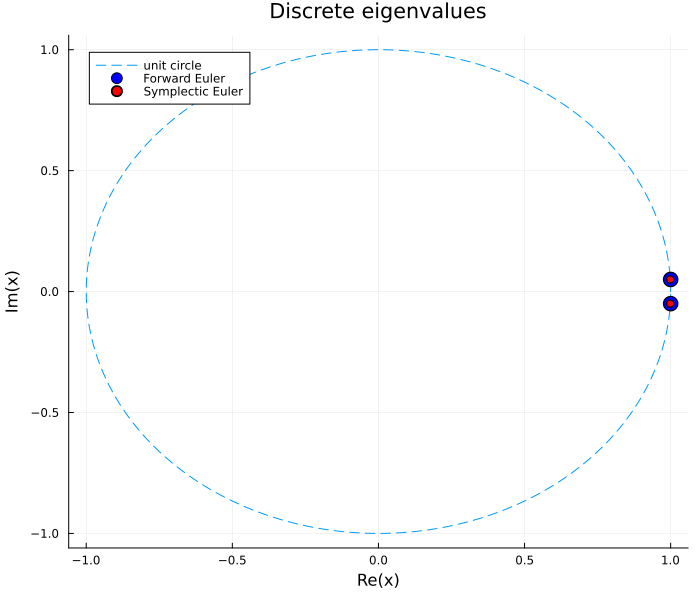

In [196]:
θ = range(0, 2π; length = 400)
Plots.plot((cos.(θ), sin.(θ)), 
linestyle = :dash, 
label = "unit circle",
title = "Discrete eigenvalues",
xlabel = "real part",
ylabel = "imaginary part",
size = (700,600))

w = sqrt(oscillator.k/oscillator.m)
Ac = [0 1; -1*w^2 0]
Afe = [1 dt; -1 * dt * w^2 1]
Ase = [1-dt^2*w^2 dt; -1 * dt * w^2 1]

eigac = eigvals(Ac)
eigafe = eigvals(Afe)
eigase = eigvals(Ase)

Plots.scatter!(eigafe, label = "Forward Euler", color=:blue, markersize = 8)
Plots.scatter!(eigase, label = "Symplectic Euler", color=:red)